In [1]:
import copy
from dataclasses import dataclass, field
import json
from typing import Dict, Sequence

from datasets import DatasetDict, load_dataset
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from tqdm import tqdm
import transformers


IGNORE_INDEX = -100
DEFAULT_PAD_TOKEN = "[PAD]"


def load_data(training_type, supervision_source, dataset_name):
    if training_type == "instruct":
        if supervision_source == "p3":
            return load_dataset("BatsResearch/bonito-experiment", "p3_1_6M")
        elif supervision_source == "dapt":
            config_name = f"unannotated_{dataset_name}"
            return load_dataset("BatsResearch/bonito-experiment", config_name)
        else:
            config_name = f"{supervision_source}_{dataset_name}"
            return load_dataset("BatsResearch/bonito-experiment", config_name)
    elif training_type == "bonito_training":
        return load_dataset("BatsResearch/ctga-v1")


def format_dataset(dataset, add_prompts=True):
    columns = (
        dataset.column_names["train"]
        if "train" in dataset
        else dataset.column_names
    )

    # TODO(kykim): This seems incorrect for other instruct models.
    def preprocess_function(examples):
        bs = len(examples[columns[0]])
        inputs = []
        outputs = []
        for i in range(bs):
            input_text = (
                "<|input|>\n" + examples["input"][i].strip() + "\n<|output|>\n"
            )
            target_text = examples["output"][i].strip()
            inputs.append(input_text)
            outputs.append(target_text)

        return {
            "input": inputs,
            "output": outputs,
        }

    if add_prompts:
        dataset = dataset.map(preprocess_function, batched=True, remove_columns=columns, num_proc=4)

    # Remove unused columns.
    dataset = dataset.remove_columns(
        [col for col in columns if col not in ["input", "output"]]
    )

    if "train" not in dataset:
        dataset = DatasetDict({"train": dataset})

    return dataset


@dataclass
class DataCollatorForCausalLM(object):
    tokenizer: transformers.PreTrainedTokenizer
    source_max_len: int = 1024
    target_max_len: int = 1024
    train_on_source: bool = False
    predict_with_generate: bool = False

    def process_instances(self, tokenizer, instances: Sequence[Dict]):
        sources = [
            f"{tokenizer.bos_token}{example['input']}" for example in instances
        ]
        targets = [
            f"{example['output']}{tokenizer.eos_token}" for example in instances
        ]

        # Tokenize
        tokenized_sources_with_prompt = tokenizer(sources, max_length=self.source_max_len, truncation=True, add_special_tokens=False)
        tokenized_targets = tokenizer(targets, max_length=self.target_max_len, truncation=True, add_special_tokens=False)

        # Build the input and labels for causal LM
        input_ids = []
        labels = []
        for tokenized_source, tokenized_target in zip(
            tokenized_sources_with_prompt["input_ids"], tokenized_targets["input_ids"]
        ):
            if not self.predict_with_generate:
                input_ids.append(torch.tensor(tokenized_source + tokenized_target))
                if not self.train_on_source:
                    labels.append(
                        torch.tensor(
                            [IGNORE_INDEX for _ in range(len(tokenized_source))]
                            + copy.deepcopy(tokenized_target)
                        )
                    )
                else:
                    labels.append(
                        torch.tensor(copy.deepcopy(tokenized_source + tokenized_target))
                    )
            else:
                input_ids.append(torch.tensor(tokenized_source))

        # Apply padding
        input_ids = pad_sequence(
            input_ids, batch_first=True, padding_value=tokenizer.pad_token_id
        )
        labels = (
            pad_sequence(labels, batch_first=True, padding_value=IGNORE_INDEX)
            if not self.predict_with_generate else None
        )
        data_dict = {
            "input_ids": input_ids,
            "attention_mask": input_ids.ne(tokenizer.pad_token_id),
        }
        if labels is not None:
            data_dict["labels"] = labels

        return data_dict

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        data_dict = self.process_instances(self.tokenizer, instances)
        return data_dict


def make_data_module(tokenizer: transformers.PreTrainedTokenizer,
                     training_type, supervision_source, dataset_name):
    dataset = load_data(training_type, supervision_source, dataset_name)
    add_prompts = True
    if training_type == "bonito_training" or supervision_source == "dapt":
        add_prompts = False

    dataset = format_dataset(dataset, add_prompts=add_prompts)

    eval_dataset_size = 0.10
    dataset = dataset["train"].train_test_split(
        test_size=eval_dataset_size, shuffle=True, seed=42
    )

    seq_collator = DataCollatorForCausalLM(
        tokenizer=tokenizer,
        source_max_len=1024,
        target_max_len=1024,
        train_on_source=False,
        predict_with_generate=False,
    )

    dataloader_params = {
        "batch_size": 4,
        "collate_fn": seq_collator,
    }
    return dataset, DataLoader(dataset["test"], **dataloader_params)

/home/kykim/miniconda3/envs/bonito/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Weight net

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

import torch
from transformers import AutoTokenizer

from training.models import LMWeightNet

/home/kykim/miniconda3/envs/bonito/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
wnet_path = "/data/kyuyoung_kim/dev/betty/examples/llm_mwn/output"

wnet = LMWeightNet("EleutherAI/pythia-70m")
wnet.load_state_dict(torch.load(os.path.join(wnet_path, "wnet_500.pt")))
wnet.eval()
wnet_tokenizer = AutoTokenizer.from_pretrained(wnet_path)
if wnet.config.pad_token_id is None:
    wnet.config.pad_token_id = wnet_tokenizer.pad_token_id

Some weights of GPTNeoXForSequenceClassification were not initialized from the model checkpoint at EleutherAI/pythia-160m and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [4]:
dataset, dataloader = make_data_module(wnet_tokenizer, training_type="instruct",
                                       supervision_source="bonito", dataset_name="pubmed_qa")

In [5]:
should_save = True

score_dicts = []
for example in tqdm(dataloader):
    input_texts = wnet_tokenizer.batch_decode(example["input_ids"], skip_special_tokens=True)
    scores = wnet(**example).squeeze(-1).detach().float().numpy()
    for input_text, score in zip(input_texts, scores):
        score_dicts.append({
            "text": input_text,
            "score": score.item(),
        })

if should_save:
    score_out_fname = os.path.join(wnet_path, "weight_net_scores.json")
    with open(score_out_fname, "w") as f:
        json.dump(score_dicts, f)

100%|██████████| 5282/5282 [10:22<00:00,  8.48it/s]


In [4]:
import collections
import json

ckpt_name = "wnet_1500"
score_out_fname = f"/data/kyuyoung_kim/dev/betty/examples/llm_mwn/output/{ckpt_name}_scores.jsonl"

score_dicts = []
with open(score_out_fname, "r") as f:
    for line in f:
        score_dicts.append(json.loads(line))

score_to_texts = collections.defaultdict(list)
for d in score_dicts:
    score_to_texts[d["score"]].append(d["text"])

Text(0, 0.5, 'proportion')

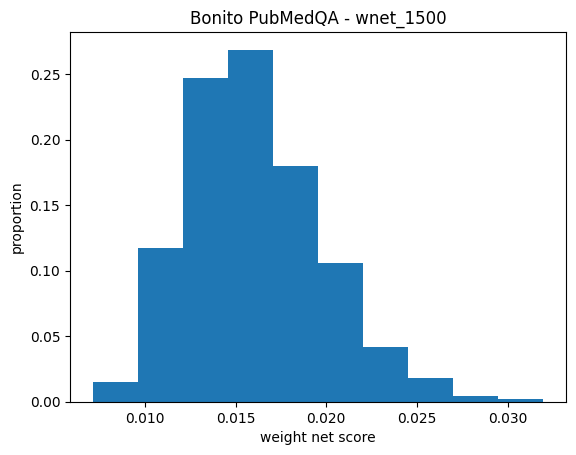

In [2]:
import matplotlib.pyplot as plt
import numpy as np

scores_all = [d["score"] for d in score_dicts]
plt.hist(scores_all, weights=np.ones(len(scores_all)) / len(scores_all), bins=10)
plt.title(f"Bonito PubMedQA - {ckpt_name}")
plt.xlabel("weight net score"); plt.ylabel("proportion")

In [11]:
scores_and_texts = sorted([(d["score"], d["text"]) for d in score_dicts])
print("lo")
for score_and_text in scores_and_texts[:5]:
    print(score_and_text)
print("\nhi")
for score_and_text in scores_and_texts[-5:]:
    print(score_and_text)

lo
(0.007110595703125, '<|input|>\nTo determine the frequency and the time to complete recovery identified by Systemic Lupus Erythematosus Disease Activity Index 2000 (SLEDAI-2K) and the time to partial recovery identified by the SLEDAI-2K Responder Index 50 (SRI-50) in three laboratory systems over 10 years. This is a retrospective analysis of the data available from the Toronto Lupus Clinic over the last 10 years. Patients with SLEDAI-2K renal, immunological and hematologic active descriptors were identified. The percentage of descriptors with partial and complete recovery was studied at one year and over the study period. Descriptive analysis and the Kaplan-Meier estimator were applied to study the time to partial and complete recovery. Of the 795 patients, 94% had an active system at some point during the study period. Partial recovery was shown in 66% of patients by SRI-50 for at least one descriptor over the study period. None of these partial findings identified would have been 

In [4]:
import collections
import json

def read_score_json(score_path):
    with open(score_path, "r") as f:
        score_dicts = json.load(f)
    score_to_texts = collections.defaultdict(list)
    for score_dict in score_dicts:
        text, score = score_dict["text"], score_dict["score"]
        score_to_texts[score].append(text)
    return score_to_texts

In [11]:
import random

base_path = "/home/kykim/dev/local/bonito-exps/output/models"
score_path = os.path.join(base_path, "meta_bonito_pubmed_qa_pythia-2.8b-Dwm/checkpoint-10000/wnet/weight_net_scores.json")
score_to_texts = read_score_json(score_path)

scores_all = list(score_to_texts.keys())
min_score, max_score = min(scores_all), max(scores_all)

for score in [min_score, max_score]:
    texts = score_to_texts[score]
    print(f"({score}):\n")
    for text in random.sample(texts, min(len(texts), 5)):
        print("---")
        print(f"{text}")
        print("---")
    print("===")

(0.37890625):

---
<|input|>
To determine the contribution of intra-alveolar cells as opposed to cells fixed in the interstitium in the development of radiation-induced lung injury. C3H/HeN mice were irradiated to the thorax with various doses of radiation. The cellular composition and cytokine production were assessed in the two sites by histological staining and RNase protection assay. Following thoracic irradiation, there was an initial decrease in the number of bronchial alveolar lavage (BAL) cells that was followed after 2 months by a dose-dependent increase up to 4 months. Foamy Mac-1 positive macrophages were present early in the BAL populations, which also expressed the pro-inflammatory cytokines TNF-alpha, IL-1alpha and IL-1beta, but this response subsided by the time of onset of pneumonitis (3 months). In contrast, in whole lung tissue there was a steady increase in Mac-1 positive cells and increased expression of TNF-alpha, IL-1alpha and IL-1beta mRNAs to maximum levels at 3

In [6]:
base_path = "/home/kykim/dev/local/bonito-exps/output/models/meta_bonito_pubmed_qa_pythia-2.8b-Dwm"
score_path1 = os.path.join(base_path, "checkpoint-10000/wnet/weight_net_scores.json")
score_path2 = os.path.join(base_path, "checkpoint-70000/wnet/weight_net_scores.json")
score_to_texts1 = read_score_json(score_path1)
score_to_texts2 = read_score_json(score_path2)

score_lens1 = [(score, len(texts)) for score, texts in sorted(score_to_texts1.items())]
score_lens2 = [(score, len(texts)) for score, texts in sorted(score_to_texts2.items())]
print(score_lens1 == score_lens2)

True


### Data

In [ ]:
from bonito import Bonito, SamplingParams
from datasets import load_dataset

# Initialize the Bonito model
bonito = Bonito("BatsResearch/bonito-v1")

# load dataaset with unannotated text
unannotated_text = load_dataset(
    "BatsResearch/bonito-experiment",
    "unannotated_contract_nli"
)["train"].select(range(10))

# Generate synthetic instruction tuning dataset
sampling_params = SamplingParams(max_tokens=256, top_p=0.95, temperature=0.5, n=1)
synthetic_dataset = bonito.generate_tasks(
    unannotated_text,
    context_col="input",
    task_type="nli",
    sampling_params=sampling_params,
)

### Autograd test

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as functional
import torch.nn.init as init

In [2]:
class HiddenLayer(nn.Module):

    def __init__(self, input_size, output_size):
        super(HiddenLayer, self).__init__()
        self.fc = nn.Linear(input_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.fc(x))


class MLP(nn.Module):

    def __init__(self, hidden_size=10, num_layers=1):
        super(MLP, self).__init__()
        self.first_hidden_layer = HiddenLayer(3, hidden_size)
        self.rest_hidden_layers = nn.Sequential(*[HiddenLayer(hidden_size, hidden_size) for _ in range(num_layers - 1)])
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.first_hidden_layer(x)
        x = self.rest_hidden_layers(x)
        x = self.output_layer(x)
        return torch.sigmoid(x)

In [3]:
mlp = MLP(hidden_size=10, num_layers=1)

In [7]:
for idx, (n, p) in enumerate(mlp.named_parameters()):
    print(f"{n}: {p.grad}")
    if idx > 3:
        break

first_hidden_layer.fc.weight: None
first_hidden_layer.fc.bias: None
output_layer.weight: None
output_layer.bias: None


In [20]:
x = torch.tensor([1., 1.5, 2.1], requires_grad=True)
y = torch.tensor([0.45, 0.78, 0.81], requires_grad=True)
y_hat = mlp(x)

In [21]:
# torch.autograd.grad()
loss = functional.mse_loss(x, y, reduction='none')
loss

tensor([0.3025, 0.5184, 1.6641], grad_fn=<MseLossBackward0>)

In [ ]:
grads = torch.autograd.grad(loss, mlp.parameters(), create_graph=True, allow_unused=False)
grads

In [28]:
x = torch.randn(2, 2)
x.requires_grad = False

lin0 = nn.Linear(2, 2)
lin1 = nn.Linear(2, 2)
lin2 = nn.Linear(2, 2)
x1 = lin0(x)
with torch.no_grad():    
    x2 = lin1(x1)
x3 = lin2(x2)
# print(torch.autograd.grad(x3.sum(), [lin0, lin1, lin2]))
x3.sum().backward()
print(lin0.weight.grad, lin1.weight.grad, lin2.weight.grad)

None None tensor([[ 0.6123, -0.4205],
        [ 0.6123, -0.4205]])


### Misc

In [7]:
import os
import shutil

In [16]:
# Remove dirs.

base_dir = "/home/kykim/dev/local/bonito-exps/output/models/meta_bonito_pubmed_qa_pythia-2.8b"
for ckpt in range(2000, 9000, 1000):
    ckpt_dir = os.path.join(base_dir, f"checkpoint-{ckpt}")
    # shutil.rmtree(ckpt_dir, ignore_errors=False)